# STEP 0: INSTALL AND IMPORT LIBRARIES
## Install necessary libraries from Hugging Face, scikit-learn, etc.

In [ ]:
!pip install wandb transformers datasets scikit-learn scikit-multilearn emoji torch --quiet

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import emoji
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from transformers import AutoTokenizer, AutoModel, Trainer, TrainingArguments
from datasets import Dataset
from skmultilearn.model_selection import iterative_train_test_split
from dataclasses import dataclass
from transformers.tokenization_utils_base import PaddingStrategy, PreTrainedTokenizerBase
from typing import Any, Dict, List, Optional, Union
import random
import torch


In [ ]:
# Fungsi untuk mengunci Random Seed
def set_seed(seed_value=42):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed_value)

# Set seed global
SEED = 42
set_seed(SEED)
print(f"Random seed telah dikunci ke: {SEED}")

# STEP 1: LOAD DATASET
## Ensure 'dataset.csv' is available in your environment.

In [ ]:
try:
    df = pd.read_csv('https://raw.githubusercontent.com/gikirima/TEA-emoji/refs/heads/v2.0/Dataset/dataset_emoji_only.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: not found. Please upload the file.")
    exit()

Dataset loaded successfully.


# STEP 2: EMOJI EXTRACTION & VOCABULARY CREATION
## Scan the dataset to build a vocabulary of unique emojis.

In [ ]:
print("\nScanning dataset for unique emojis...")
unique_emojis = set()
for text in df['text'].dropna():
    text_str = str(text)
    for character in text_str:
        if emoji.is_emoji(character):
            unique_emojis.add(character)

# Create a mapping from emoji to integer ID. ID 0 is reserved for padding.
emoji_list = sorted(list(unique_emojis))
emoji_to_id = {em: i for i, em in enumerate(emoji_list, 1)}
emoji_to_id['<PAD>'] = 0
id_to_emoji = {i: em for em, i in emoji_to_id.items()}
EMOJI_VOCAB_SIZE = len(emoji_to_id)
EMOJI_PAD_ID = emoji_to_id['<PAD>']

print(f"Found {len(unique_emojis)} unique emojis.")
print(f"Emoji vocabulary size (including <PAD>): {EMOJI_VOCAB_SIZE}")


Scanning dataset for unique emojis...
Found 1040 unique emojis.
Emoji vocabulary size (including <PAD>): 1041


# STEP 3: DEFINE CUSTOM MODEL (EARLY FUSION WITH CROSS-ATTENTION)
## This model architecture is based on the provided diagram.

In [ ]:
class BertEmojiCrossAttentionModel(nn.Module):
    """
    Custom model fusing IndoBERT and emoji embeddings via cross-attention.

    The text's hidden states act as the 'query', while the emoji embeddings
    act as the 'key' and 'value'. The model then fuses the original text
    summary ([CLS] token) with the new emoji-aware text summary.
    """
    def __init__(self, model_name, num_labels, emoji_vocab_size, emoji_emb_dim=256, num_attention_heads=8, dropout_rate=0.2):
        super().__init__()
        self.num_labels = num_labels

        # 1. Base BERT model
        self.bert = AutoModel.from_pretrained(model_name)
        bert_hidden_size = self.bert.config.hidden_size

        # 2. Emoji processing layers
        self.emoji_embeddings = nn.Embedding(emoji_vocab_size, emoji_emb_dim, padding_idx=EMOJI_PAD_ID)
        self.emoji_projection = nn.Linear(emoji_emb_dim, bert_hidden_size)

        # 3. Cross-Attention layer
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=bert_hidden_size,
            num_heads=num_attention_heads,
            batch_first=True  # Crucial for Hugging Face model outputs
        )

        # 4. Classifier head (MLP)
        # Input is the concatenation of two [CLS] vectors, as per the diagram.
        self.classifier = nn.Sequential(
            nn.Linear(bert_hidden_size * 2, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_labels)
        )

        # Compatibility with Hugging Face Trainer
        self.config = self.bert.config
        self.config.problem_type = "multi_label_classification"

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        emoji_ids: torch.Tensor,
        labels: Optional[torch.Tensor] = None
    ):
        # 1. Get raw text features from BERT
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_hidden_states = bert_outputs.last_hidden_state  # Shape: [B, T, H]
        cls_text_only = text_hidden_states[:, 0, :] # [CLS] from raw text

        # 2. Get emoji features
        emoji_embs = self.emoji_embeddings(emoji_ids) # Shape: [B, E, Emb_Dim]
        projected_emoji_embs = self.emoji_projection(emoji_embs) # Shape: [B, E, H]

        # 3. Perform Cross-Attention
        # Query: Text hidden states
        # Key/Value: Projected emoji embeddings
        # We need a mask to ignore PAD emojis in the key/value pairs.
        emoji_padding_mask = (emoji_ids == EMOJI_PAD_ID) # Shape: [B, E]

        emoji_aware_hidden_states, _ = self.cross_attention(
            query=text_hidden_states,
            key=projected_emoji_embs,
            value=projected_emoji_embs,
            key_padding_mask=emoji_padding_mask
        ) # Shape: [B, T, H]
        cls_cross_attention = emoji_aware_hidden_states[:, 0, :] # [CLS] from emoji-aware states

        # 4. Fusion
        # Concatenate the two [CLS] representations as per the diagram
        fused_vector = torch.cat((cls_text_only, cls_cross_attention), dim=1) # Shape: [B, 2*H]

        # 5. Classification
        logits = self.classifier(fused_vector)

        # 6. Calculate loss if labels are provided
        loss = None
        if labels is not None:
            loss_fct = nn.BCEWithLogitsLoss()
            loss = loss_fct(logits, labels.float())

        return (loss, logits) if loss is not None else (logits,)

# --- Initialize Model and Tokenizer ---
model_name = "indobenchmark/indobert-base-p1"
label_columns = ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']
num_labels = len(label_columns)
EMOJI_EMBEDDING_DIM = 128 # INI HYPERPARAMETER YANG BISA DIUBAH

print(f"\nLoading tokenizer '{model_name}'...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Initializing custom model 'BertEmojiCrossAttentionModel'...")
model = BertEmojiCrossAttentionModel(
    model_name=model_name,
    num_labels=num_labels,
    emoji_vocab_size=EMOJI_VOCAB_SIZE,
    emoji_emb_dim=EMOJI_EMBEDDING_DIM
)
print("Model and tokenizer are ready.")


Loading tokenizer 'indobenchmark/indobert-base-p1'...
Initializing custom model 'BertEmojiCrossAttentionModel'...
Model and tokenizer are ready.


# STEP 4: PREPARE DATASET FOR HUGGING FACE
## Split data into training, validation, and test sets.

In [ ]:
print("\nSplitting dataset using iterative_train_test_split...")
X = df['text'].to_numpy().reshape(-1, 1)
y = df[label_columns].to_numpy()

# Stratified split for multi-label data
X_train_val, y_train_val, X_test, y_test = iterative_train_test_split(X, y, test_size=0.2)
X_train, y_train, X_val, y_val = iterative_train_test_split(X_train_val, y_train_val, test_size=0.2)

df_train = pd.DataFrame(X_train.flatten(), columns=['text'])
for i, col in enumerate(label_columns): df_train[col] = y_train[:, i]

df_val = pd.DataFrame(X_val.flatten(), columns=['text'])
for i, col in enumerate(label_columns): df_val[col] = y_val[:, i]

df_test = pd.DataFrame(X_test.flatten(), columns=['text'])
for i, col in enumerate(label_columns): df_test[col] = y_test[:, i]

print("\nConverting DataFrames to Hugging Face Datasets...")
train_dataset_hf = Dataset.from_pandas(df_train)
eval_dataset_hf = Dataset.from_pandas(df_val)
test_dataset_hf = Dataset.from_pandas(df_test)

# --- Preprocessing Function ---
def preprocess_data(examples):
    # 1. Tokenize text for BERT
    tokenized_output = tokenizer(
        examples["text"], padding=False, truncation=True, max_length=128
    )

    # 2. Extract and map emojis to their IDs
    all_emoji_ids = []
    texts = [str(t) for t in examples["text"]]
    for text in texts:
        ids = [emoji_to_id.get(char) for char in text if emoji.is_emoji(char) and char in emoji_to_id]
        ids = [id for id in ids if id is not None]
        if not ids:
            ids = [EMOJI_PAD_ID] # Use a single PAD token if no emojis are present
        all_emoji_ids.append(ids)

    # 3. Format labels
    labels = [[float(examples[label][i]) for label in label_columns] for i in range(len(texts))]

    tokenized_output["emoji_ids"] = all_emoji_ids
    tokenized_output["labels"] = labels
    return tokenized_output

print("\nTokenizing text and extracting emojis for all datasets...")
train_dataset = train_dataset_hf.map(preprocess_data, batched=True, remove_columns=train_dataset_hf.column_names)
eval_dataset = eval_dataset_hf.map(preprocess_data, batched=True, remove_columns=eval_dataset_hf.column_names)
test_dataset = test_dataset_hf.map(preprocess_data, batched=True, remove_columns=test_dataset_hf.column_names)

print("\n--- Data Splitting and Preprocessing Complete ---")
print(f"Training data count: {len(train_dataset)}")
print(f"Validation data count: {len(eval_dataset)}")
print(f"Test data count: {len(test_dataset)}")



Splitting dataset using iterative_train_test_split...

Converting DataFrames to Hugging Face Datasets...

Tokenizing text and extracting emojis for all datasets...


Map:   0%|          | 0/89262 [00:00<?, ? examples/s]

Map:   0%|          | 0/22112 [00:00<?, ? examples/s]

Map:   0%|          | 0/28040 [00:00<?, ? examples/s]


--- Data Splitting and Preprocessing Complete ---
Training data count: 89262
Validation data count: 22112
Test data count: 28040


In [ ]:
# --- HITUNG CLASS WEIGHTS (Penanganan Imbalance) ---

# Ambil array label (0 atau 1) dari DataFrame df_train
labels_array = df_train[label_columns].to_numpy()

# Hitung jumlah sampel positif dan negatif per label
num_positives = labels_array.sum(axis=0)
num_negatives = labels_array.shape[0] - num_positives

# Rumus: pos_weight = jumlah_negatif / jumlah_positif
# Ditambah epsilon (1e-5) agar tidak error division by zero
pos_weights_tensor = torch.tensor((num_negatives / (num_positives + 1e-5)), dtype=torch.float)

# Pindahkan ke GPU agar kompatibel saat training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weights_tensor = pos_weights_tensor.to(device)

print("\nClass Weights (pos_weight) berhasil dihitung:")
for label, weight in zip(label_columns, pos_weights_tensor):
    print(f"- {label}: {weight.item():.4f}")

# STEP 4.5: CREATE CUSTOM DATA COLLATOR
## This collator handles dynamic padding for both text and emoji ID sequences.

In [ ]:
@dataclass
class CustomDataCollator:
    tokenizer: PreTrainedTokenizerBase
    padding: Union[bool, str, PaddingStrategy] = True
    max_length: Optional[int] = None
    pad_to_multiple_of: Optional[int] = None

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, Any]:
        labels = [feature.pop("labels") for feature in features]
        emoji_ids = [feature.pop("emoji_ids") for feature in features]

        # Use the tokenizer's default padding for text-based inputs
        batch = self.tokenizer.pad(
            features,
            padding=self.padding,
            max_length=self.max_length,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",
        )

        # Manually pad the emoji_ids sequences
        max_emoji_len = max(len(ids) for ids in emoji_ids)
        padded_emoji_ids = [ids + [EMOJI_PAD_ID] * (max_emoji_len - len(ids)) for ids in emoji_ids]

        # Add the padded data back to the batch
        batch["labels"] = torch.tensor(labels, dtype=torch.float)
        batch["emoji_ids"] = torch.tensor(padded_emoji_ids, dtype=torch.long)

        return batch

data_collator = CustomDataCollator(tokenizer=tokenizer)

# STEP 5: DEFINE EVALUATION METRICS
## Function to compute performance metrics for multi-label classification.

In [ ]:
def compute_metrics(p):
    logits, labels = p
    preds_proba = torch.sigmoid(torch.tensor(logits))
    # Use a 0.5 threshold to binarize predictions
    preds = (preds_proba > 0.5).int().numpy()
    labels = labels.astype(int)

    f1_macro = f1_score(labels, preds, average='macro', zero_division=0)
    f1_micro = f1_score(labels, preds, average='micro', zero_division=0)
    precision_micro = precision_score(labels, preds, average='micro', zero_division=0)
    recall_micro = recall_score(labels, preds, average='micro', zero_division=0)

    return {
        'f1_macro': f1_macro,
        'f1_micro': f1_micro,
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'accuracy': accuracy_score(labels, preds), # Exact match ratio
    }


# STEP 6: CONFIGURE AND RUN TRAINING
## Set up training arguments and initialize the Hugging Face Trainer.

In [ ]:
# 1. Custom Trainer Khusus untuk Model Cross Attention (Tuple Output)
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)

        # [PENTING] Model Cross Attention mengembalikan tuple (loss, logits)
        # Kita ambil logits dari indeks ke-1
        if isinstance(outputs, tuple):
            logits = outputs[1]
        elif hasattr(outputs, 'logits'):
            logits = outputs.logits
        else:
            logits = outputs

        # Menggunakan BCEWithLogitsLoss dengan pos_weight
        loss_fct = nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor)
        loss = loss_fct(logits, labels.float())

        return (loss, outputs) if return_outputs else loss

In [ ]:
# WANDB integration for experiment tracking.
try:
    from google.colab import userdata
    wandb_api_key = userdata.get('WANDB_API_KEY')
    import wandb
    if wandb_api_key:
        wandb.login(key=wandb_api_key)
        print("WANDB login successful.")
        wandb.init(
            project="EF_CrossAttention_Model",
            name="training_run_8",
        )
    else:
        print("WANDB_API key not found. Skipping WANDB logging.")
        report_to = "none"
except (ImportError, KeyError):
    print("Not in Colab or WANDB key not set. Skipping WANDB logging.")
    report_to = "none"


training_args = TrainingArguments(
    output_dir="./results_cross_attention",
    eval_strategy="steps",
    save_strategy="steps",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=250,
    eval_steps=1500,
    save_steps=1500,
    save_total_limit=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    learning_rate=3e-5,
    warmup_steps=500,
    weight_decay=0.01,
    fp16=True, # Requires a GPU with Tensor Cores
    report_to="wandb",
    seed=SEED,
    data_seed=SEED
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("\nMemulai proses fine-tuning model (Cross Attention) dengan Class Weights & Seed...")
trainer.train()

print("\nPelatihan selesai.")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: fikrihanif130 (hydrarkmi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WANDB login successful.


/tmp/ipython-input-3252995367.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



Starting model fine-tuning with Cross-Attention fusion...


You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss,Validation Loss,F1 Macro,F1 Micro,Precision Micro,Recall Micro,Accuracy
1500,0.234900,0.215890,0.590990,0.798731,0.854190,0.750035,0.505879
3000,0.218300,0.199101,0.639404,0.825500,0.833373,0.817774,0.552641
4500,0.214800,0.194186,0.672489,0.828140,0.836966,0.819499,0.565711
6000,0.165100,0.185888,0.720575,0.836227,0.836860,0.835594,0.576746
7500,0.165200,0.191406,0.702451,0.834842,0.844791,0.825124,0.583303
9000,0.165800,0.177329,0.730125,0.843611,0.848686,0.838596,0.595152
10500,0.168500,0.176285,0.718664,0.849104,0.857088,0.841267,0.603292
12000,0.127900,0.188522,0.727645,0.841413,0.843723,0.839116,0.586695
13500,0.122100,0.186203,0.743731,0.849155,0.837920,0.860695,0.598996
15000,0.123600,0.191170,0.734118,0.844502,0.841775,0.847247,0.595423



Training complete.


# STEP 7: FINAL EVALUATION
## Evaluate the best model on the held-out test set.


Evaluating the best model on the test set...



Final Evaluation Results:
{'eval_loss': 0.19313138723373413, 'eval_f1_macro': 0.7309618719193225, 'eval_f1_micro': 0.8417724461803134, 'eval_precision_micro': 0.8275887289948618, 'eval_recall_micro': 0.8564508193619196, 'eval_accuracy': 0.5894793152639087, 'eval_runtime': 29.6122, 'eval_samples_per_second': 946.906, 'eval_steps_per_second': 59.199, 'epoch': 4.0}

Generating predictions for confusion matrix...

Creating confusion matrix plots for each label...
Confusion matrix plot saved to: ./fine_tuned_cross_attention_model/confusion_matrix.png


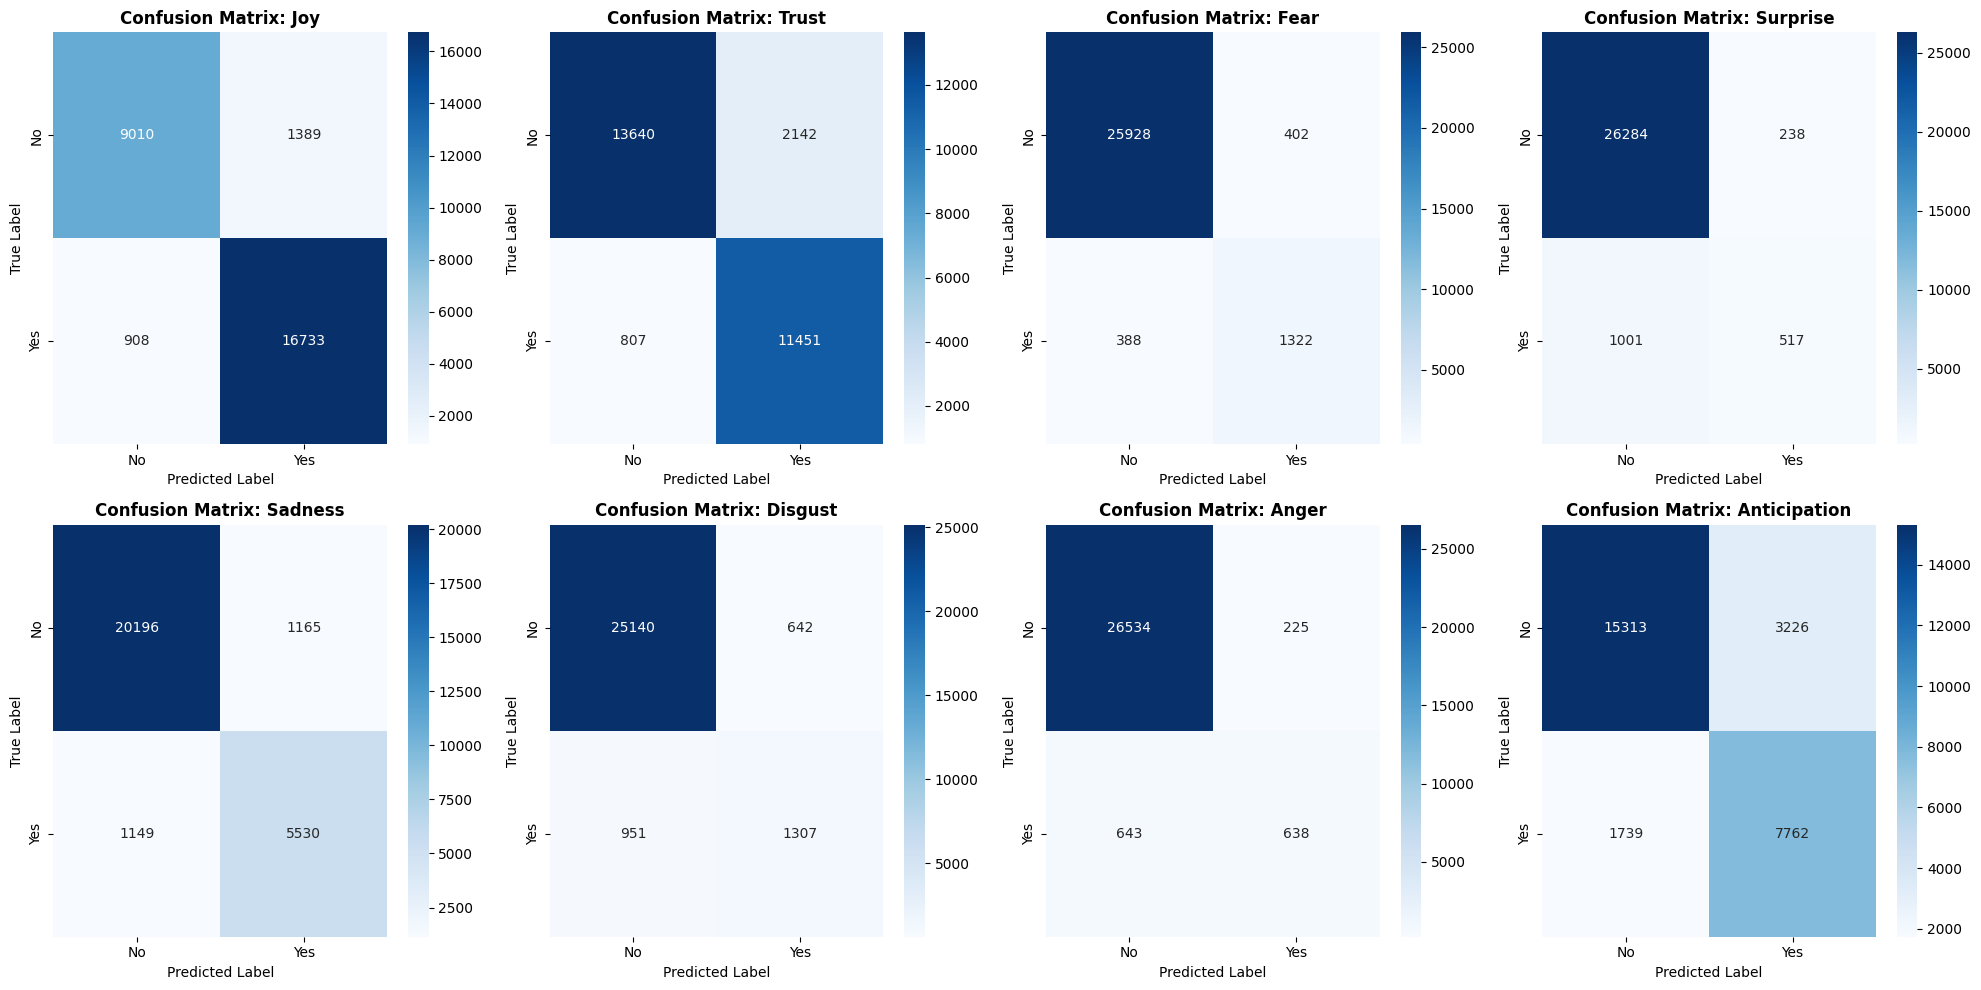

Logging artifacts to W&B...


<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== 1. PENCARIAN DYNAMIC THRESHOLD (MENGGUNAKAN VALIDATION SET) ===")

# Ambil prediksi mentah (logits) dari data VALIDASI
val_output = trainer.predict(eval_dataset)
val_logits = val_output.predictions
val_labels = val_output.label_ids

# Ubah logits ke probabilitas (Sigmoid)
val_probs = torch.sigmoid(torch.tensor(val_logits)).numpy()

# Cari threshold terbaik untuk SETIAP label
best_thresholds = np.full(num_labels, 0.5)
search_range = np.arange(0.1, 0.95, 0.05)

print("Mengoptimalkan threshold per label...")
for i in range(num_labels):
    best_f1 = 0
    best_thresh = 0.5
    for thresh in search_range:
        preds = (val_probs[:, i] > thresh).astype(int)
        current_f1 = f1_score(val_labels[:, i], preds, zero_division=0)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_thresh = thresh

    best_thresholds[i] = best_thresh

# Tampilkan Threshold terpilih
thresh_df = pd.DataFrame({'Label': label_columns, 'Optimized Threshold': best_thresholds})
print(thresh_df)


print("\n=== 2. EVALUASI TEST SET (DENGAN DYNAMIC THRESHOLD) ===")

# Ambil prediksi mentah dari data TEST
test_output = trainer.predict(test_dataset)
test_probs = torch.sigmoid(torch.tensor(test_output.predictions)).numpy()
test_labels_true = test_output.label_ids

# Array untuk menyimpan prediksi final
final_test_preds = np.zeros_like(test_probs, dtype=int)

# Terapkan threshold yang sudah dioptimalkan
for i in range(num_labels):
    final_test_preds[:, i] = (test_probs[:, i] > best_thresholds[i]).astype(int)

# --- HITUNG METRIK ---

# 1. Metrik Global
global_acc = accuracy_score(test_labels_true, final_test_preds)
global_f1_macro = f1_score(test_labels_true, final_test_preds, average='macro')
global_f1_micro = f1_score(test_labels_true, final_test_preds, average='micro')

print(f"\n[Global Metrics]")
print(f"Accuracy (Exact Match): {global_acc:.4f}")
print(f"F1 Macro Average      : {global_f1_macro:.4f}")
print(f"F1 Micro Average      : {global_f1_micro:.4f}")

# 2. Metrik Per Kelas
f1_per_class = f1_score(test_labels_true, final_test_preds, average=None)
prec_per_class = precision_score(test_labels_true, final_test_preds, average=None, zero_division=0)
rec_per_class = recall_score(test_labels_true, final_test_preds, average=None, zero_division=0)

# Buat DataFrame Laporan
df_metrics = pd.DataFrame({
    'Label': label_columns,
    'Threshold': best_thresholds,
    'Precision': prec_per_class,
    'Recall': rec_per_class,
    'F1-Score': f1_per_class
})

print("\n[Detailed Metrics Per Class]")
print(df_metrics.round(4).to_string(index=False))

# 3. Tampilkan Classification Report standar
print("\n--- SKLEARN CLASSIFICATION REPORT ---")
print(classification_report(test_labels_true, final_test_preds, target_names=label_columns, zero_division=0))

# --- VISUALISASI CONFUSION MATRIX ---
print("\n=== 3. VISUALISASI CONFUSION MATRIX ===")

# Siapkan grid plot
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, label_name in enumerate(label_columns):
    # Hitung CM menggunakan prediksi yang sudah di-threshold
    cm = confusion_matrix(
        y_true=test_labels_true[:, i],
        y_pred=final_test_preds[:, i]
    )

    # Plot Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])

    axes[i].set_title(f"{label_name.title()} (Thresh: {best_thresholds[i]:.2f})", fontweight='bold')
    axes[i].set_xlabel('Prediksi')
    axes[i].set_ylabel('Aktual')

plt.tight_layout()
plt.show()


# save plot to drive
# --- Generate, Save, and Log Confusion Matrix Plot ---
final_model_path = "./fine_tuned_indobert_cross_attn"
os.makedirs(final_model_path, exist_ok=True)
cm_plot_path = os.path.join(final_model_path, "confusion_matrices.png")
fig.savefig(cm_plot_path)
print(f"\nConfusion matrix plot saved to: {cm_plot_path}")

# simpan laporan metrik ke CSV
metrics_csv_path = os.path.join(final_model_path, "detailed_metrics_per_class.csv")
df_metrics.to_csv(metrics_csv_path, index=False)
print(f"Detailed metrics per class saved to: {metrics_csv_path}")

# simpan laporan global metrik ke TXT
global_metrics_txt_path = os.path.join(final_model_path, "global_metrics.txt")
with open(global_metrics_txt_path, 'w') as f:
    f.write(f"Global Metrics:\n")
    f.write(f"Accuracy (Exact Match): {global_acc:.4f}\n")
    f.write(f"F1 Macro Average      : {global_f1_macro:.4f}\n")
    f.write(f"F1 Micro Average      : {global_f1_micro:.4f}\n")
print(f"Global metrics saved to: {global_metrics_txt_path}")

# simpan classification report ke TXT
classification_report_txt_path = os.path.join(final_model_path, "classification_report.txt")
with open(classification_report_txt_path, 'w') as f:
    f.write(classification_report(test_labels_true, final_test_preds, target_names=label_columns, zero_division=0))
print(f"Classification report saved to: {classification_report_txt_path}")

In [ ]:
# --- TAMBAHAN: LOGGING MANUAL KE WANDB ---
import wandb

# Cek apakah W&B sedang aktif
if wandb.run is not None:
    print("\nMengirim hasil evaluasi Dynamic Threshold ke W&B...")

    # 1. Log Metrik Global (dengan suffix '_dynamic' agar beda dengan default)
    wandb.log({
        "test/accuracy_dynamic": accuracy_score(test_labels_true, final_test_preds),
        "test/f1_macro_dynamic": f1_score(test_labels_true, final_test_preds, average='macro'),
        "test/f1_micro_dynamic": f1_score(test_labels_true, final_test_preds, average='micro'),
    })

    # 2. Log Metrik Per Label & Threshold yang dipakai
    for i, label in enumerate(label_columns):
        wandb.log({
            f"test_per_class/f1_{label}": f1_score(test_labels_true[:, i], final_test_preds[:, i], zero_division=0),
            f"test_per_class/threshold_{label}": best_thresholds[i]
        })

    # 3. Log Hyperparameter Bobot (w1, w2) - Penting untuk tuning!
    # Mengakses atribut w1/w2 dari model (pastikan model masih ada di memori)
    if hasattr(model, 'w1') and hasattr(model, 'w2'):
        wandb.log({
            "hyperparams/weight_text (w1)": model.w1,
            "hyperparams/weight_emoji (w2)": model.w2
        })

    # 4. Log Gambar Confusion Matrix
    # 'fig' diambil dari plot matplotlib di kode sebelumnya
    wandb.log({"confusion_matrix_dynamic": wandb.Image(fig)})

    print("Log ke W&B berhasil.")
else:
    print("\nW&B run tidak terdeteksi. Hasil tidak di-upload.")

# STEP 8: SAVE FINAL MODEL AND ASSETS
# Save the model's state, tokenizer, and emoji vocabulary for future use.

In [ ]:
# --- LANGKAH 8: MENYIMPAN MODEL, TOKENIZER, DAN ARTIFAK FINAL ---
import os
import json
import torch
import shutil
import wandb
from google.colab import drive

# 1. Konfigurasi Path Penyimpanan Lokal
# Saya beri nama folder yang spesifik agar tidak tertukar
if not os.path.exists(final_model_path):
    os.makedirs(final_model_path)

print(f"Menyimpan model ke folder lokal: '{final_model_path}'...")

# 2. Simpan Model (State Dict)
# [PENTING] Untuk arsitektur Custom (Cross Attention), simpan state_dict adalah cara paling aman
torch.save(model.state_dict(), os.path.join(final_model_path, "pytorch_model.bin"))

# 3. Simpan Tokenizer & Config
tokenizer.save_pretrained(final_model_path)
# Simpan config dasar IndoBERT (agar saat load nanti kita tahu base modelnya apa)
model.bert.config.save_pretrained(final_model_path)

# 4. Simpan Dictionary Emoji (Sangat Penting untuk Early Fusion)
# Kita butuh ini saat inference untuk memetakan emoji ke ID
if 'emoji_to_id' in globals():
    with open(os.path.join(final_model_path, "emoji_to_id.json"), 'w') as f:
        json.dump(emoji_to_id, f)
    print("Mapping emoji_to_id berhasil disimpan.")
else:
    print("PERINGATAN: Variabel 'emoji_to_id' tidak ditemukan. Mapping tidak tersimpan!")

print("Model, Tokenizer, dan Artifak berhasil disimpan secara lokal.")

# 5. Logging Metrik Final ke WandB
if wandb.run is not None:
    print("\nMengirim metrik final ke WandB...")
    try:
        # Menggunakan variabel global yang kita hitung di Langkah 7
        wandb.log({
            "final/accuracy": global_acc,
            "final/f1_macro": global_f1_macro,
            "final/f1_micro": global_f1_micro
        })
        print("Metrik final terkirim.")
    except NameError:
        print("Gagal log metrik: Variabel dari Langkah 7 tidak ditemukan.")

    wandb.finish()
    print("Sesi WandB ditutup.")

# 6. Simpan ke Google Drive (Backup Otomatis)
print("\n--- MENYALIN KE GOOGLE DRIVE ---")
try:
    drive.mount('/content/drive')

    # Tentukan lokasi penyimpanan di Drive
    # Sesuaikan path ini dengan struktur folder Drive kamu
    drive_save_path = "/content/drive/MyDrive/TEA Multi Modal Project/Model_v2/EF_CrossAttn/run_1/"

    if not os.path.exists(drive_save_path):
        os.makedirs(drive_save_path)

    # Salin seluruh folder lokal ke Drive
    shutil.copytree(final_model_path, drive_save_path, dirs_exist_ok=True)
    print(f"Sukses! Model berhasil disalin ke: {drive_save_path}")

except Exception as e:
    print(f"Gagal menyalin ke Google Drive: {e}")


Saving final model and assets to './fine_tuned_cross_attention_model'...
Model, tokenizer, and emoji vocab saved successfully.


eval/accuracy,▁▄▅▆▇▇█▇█▇▇▇▇▇▇
eval/f1_macro,▁▃▅▇▆▇▇▇██████▇
eval/f1_micro,▁▅▅▆▆▇█▇█▇█▇▇▇▇
eval/loss,█▅▄▃▄▁▁▃▃▄▄▆▇▇▄
eval/precision_micro,▇▂▃▃▅▆█▅▃▄▄▄▄▄▁
eval/recall_micro,▁▅▅▆▆▇▇▇█▇▇▇▇▇█
eval/runtime,▁▁▁▁▁▁▁▁▁▁▁▁▁▁█
eval/samples_per_second,▆▆▇▄█▄▅▄▃▁▅▄▁▁▁
eval/steps_per_second,▆▆▇▄█▄▅▄▃▁▅▄▁▁▁
test/accuracy,▁
+13,...


W&B run finished.


# Simpan ke Google Drive

In [ ]:
from google.colab import drive
import os
import shutil

# Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

# Tentukan path untuk menyimpan model di Google Drive
# Pastikan folder 'training 1' ada di root Google Drive Anda atau sesuaikan path
drive_save_path = "/content/drive/MyDrive/fine_tuned_indobert_EF_CrossAttn/training 8"

# Buat direktori jika belum ada
if not os.path.exists(drive_save_path):
    os.makedirs(drive_save_path)
    print(f"Direktori '{drive_save_path}' dibuat.")
else:
    print(f"Direktori '{drive_save_path}' sudah ada.")

# Tentukan path folder yang ingin disalin
source_folder = "/content/fine_tuned_cross_attention_model"

# Menyalin seluruh isi folder ke Google Drive
print(f"\nMenyalin isi folder '{source_folder}' ke '{drive_save_path}'...")
# Use shutil.copytree to copy the entire directory
try:
    # If directory already exists, remove it first to avoid errors
    if os.path.exists(drive_save_path):
      shutil.rmtree(drive_save_path)
    shutil.copytree(source_folder, drive_save_path)
    print("Isi folder berhasil disalin ke Google Drive.")
except Exception as e:
    print(f"Gagal menyalin folder: {e}")

# # Ini adalah kode sebelumnya untuk menyimpan model menggunakan trainer,
# # yang mungkin tidak menyalin semua file di folder.
# # trainer.save_model(drive_save_path)
# tokenizer.save_pretrained(drive_save_path) # Ini sudah disalin di copytree
# print("Model dan tokenizer berhasil disimpan di Google Drive.")

Mounting Google Drive...
Mounted at /content/drive
Direktori '/content/drive/MyDrive/fine_tuned_indobert_EF_CrossAttn/training 8' dibuat.

Menyalin isi folder '/content/fine_tuned_cross_attention_model' ke '/content/drive/MyDrive/fine_tuned_indobert_EF_CrossAttn/training 8'...
Isi folder berhasil disalin ke Google Drive.
